## Pull data

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

idealPoints10to20 = pd.read_csv("postprocess/deviationAnalysis/ideal10to20.csv")
idealPoints20to30 = pd.read_csv("postprocess/deviationAnalysis/ideal20to30.csv")
idealPoints30to40 = pd.read_csv("postprocess/deviationAnalysis/ideal30to40.csv")

pinsga2Tabs =   {1988  : pd.read_csv("postprocess/eaf/1988-pinsga2.csv"), 
                1989  : pd.read_csv("postprocess/eaf/1989-pinsga2.csv"), 
                1990  : pd.read_csv("postprocess/eaf/1990-pinsga2.csv"),  
                1991  : pd.read_csv("postprocess/eaf/1991-pinsga2.csv"),  
                1992  : pd.read_csv("postprocess/eaf/1992-pinsga2.csv"),  
                1993  : pd.read_csv("postprocess/eaf/1993-pinsga2.csv"),  
                1994  : pd.read_csv("postprocess/eaf/1994-pinsga2.csv"), 
                1995  : pd.read_csv("postprocess/eaf/1995-pinsga2.csv"), 
                1996  : pd.read_csv("postprocess/eaf/1996-pinsga2.csv"), 
                1997  : pd.read_csv("postprocess/eaf/1997-pinsga2.csv"), 
                1998  : pd.read_csv("postprocess/eaf/1998-pinsga2.csv"), 
                1999  : pd.read_csv("postprocess/eaf/1999-pinsga2.csv"), 
                2000  : pd.read_csv("postprocess/eaf/2000-pinsga2.csv"), 
                2001  : pd.read_csv("postprocess/eaf/2001-pinsga2.csv"), 
                2002  : pd.read_csv("postprocess/eaf/2002-pinsga2.csv"), 
                2003  : pd.read_csv("postprocess/eaf/2003-pinsga2.csv"), 
                2004  : pd.read_csv("postprocess/eaf/2004-pinsga2.csv"), 
                2005  : pd.read_csv("postprocess/eaf/2005-pinsga2.csv"), 
                2006  : pd.read_csv("postprocess/eaf/2006-pinsga2.csv"), 
                2007  : pd.read_csv("postprocess/eaf/2007-pinsga2.csv"), 
                2008  : pd.read_csv("postprocess/eaf/2008-pinsga2.csv"), 
                2009  : pd.read_csv("postprocess/eaf/2009-pinsga2.csv"), 
                2010  : pd.read_csv("postprocess/eaf/2010-pinsga2.csv"), 
                2011  : pd.read_csv("postprocess/eaf/2011-pinsga2.csv"), 
                2012  : pd.read_csv("postprocess/eaf/2012-pinsga2.csv"), 
                2013  : pd.read_csv("postprocess/eaf/2013-pinsga2.csv"), 
                2014  : pd.read_csv("postprocess/eaf/2014-pinsga2.csv"), 
                2015  : pd.read_csv("postprocess/eaf/2015-pinsga2.csv"), 
                2016  : pd.read_csv("postprocess/eaf/2016-pinsga2.csv"), 
                2017  : pd.read_csv("postprocess/eaf/2017-pinsga2.csv") }




## 10 to 20 

In [6]:
normalized_pinsga2_list = []

for year in range(1988, 2018):
  ideal_yield = float(idealPoints10to20.loc[idealPoints10to20.loc[:,"year"] == year,"yield"])
  ideal_irr = float(idealPoints10to20.loc[idealPoints10to20.loc[:,"year"] == year,"irr"])

  # Pull out the year we want 
  pinsga2_for_year = pinsga2Tabs[year]
  pinsga2_normalized = pinsga2_for_year.loc[pinsga2_for_year.loc[:,"DM_range"] == "10to20",:]

  # Normalize 
  pinsga2_normalized.loc[:,"normYield"] =  pinsga2_normalized.loc[:,"V2"] - ideal_yield
  pinsga2_normalized.loc[:,"normIrr"] =  pinsga2_normalized.loc[:,"V1"] - ideal_irr

  # Add year into there
  pinsga2_normalized.loc[:, "year"] = year

  normalized_pinsga2_list.append(pinsga2_normalized)

# Pull them all together
normalized_pinsga2 = pd.concat(normalized_pinsga2_list)


C:\Users\i-kropp\AppData\Local\Temp\ipykernel_24392\237265284.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ideal_yield = float(idealPoints10to20.loc[idealPoints10to20.loc[:,"year"] == year,"yield"])
C:\Users\i-kropp\AppData\Local\Temp\ipykernel_24392\237265284.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ideal_irr = float(idealPoints10to20.loc[idealPoints10to20.loc[:,"year"] == year,"irr"])
C:\Users\i-kropp\AppData\Local\Temp\ipykernel_24392\237265284.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pinsga2_normalized.loc[:,"normYield

## Outlier removal 

In [ ]:

no_outlier_mask = np.logical_and(
  np.abs(stats.zscore(normalized_pinsga2.loc[:,"normYield"])) < 3, 
  np.abs(stats.zscore(normalized_pinsga2.loc[:,"normIrr"])) < 3)

normalized_pinsga2 = normalized_pinsga2.loc[no_outlier_mask, :]
  

## Plotting

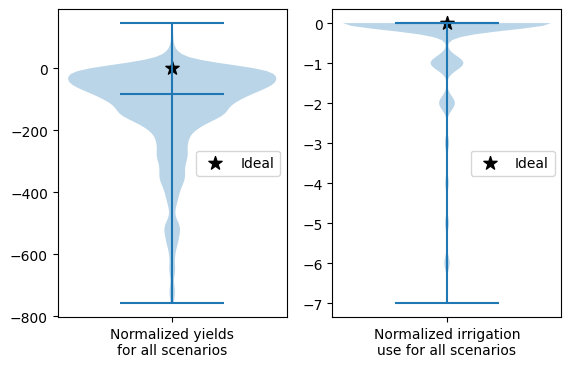

In [26]:

# Get raw data for plotting
yield_data = normalized_pinsga2.loc[:,["normYield"]].values
irr_data = normalized_pinsga2.loc[:,["normIrr"]].values

# Plot 
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6.5, 4))
axs[0].violinplot(yield_data, showmedians=True);
axs[1].violinplot(irr_data, showmedians=True);


# Add stars at 0 for each subplot
axs[0].scatter(1, 0, color='black', marker='*', s=100, label='Ideal')
axs[1].scatter(1, 0, color='black', marker='*', s=100, label='Ideal')
axs[0].set_xticks([1], labels=["Normalized yields\nfor all scenarios"])
axs[1].set_xticks([1], labels=["Normalized irrigation\nuse for all scenarios"])


# Optional: Add labels or a legend
axs[0].legend(loc="center right")
axs[1].legend(loc="center right")

